In [ ]:
# Problem 1 - Multivariate Linear Regression
# Employee Productivity Score Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

   Experience  TrainingHours  WorkingHours  Projects  ProductivityScore
0           2             40            38         3                 62
1           5             60            42         6                 78
2           1             20            35         2                 55
3           8             80            45         8                 88
4           4             50            40         5                 72

Shape: (10, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Experience         10 non-null     int64
 1   TrainingHours      10 non-null     int64
 2   WorkingHours       10 non-null     int64
 3   Projects           10 non-null     int64
 4   ProductivityScore  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
       Experience  TrainingHours  WorkingHours   Projects  ProductivityScore
count   1

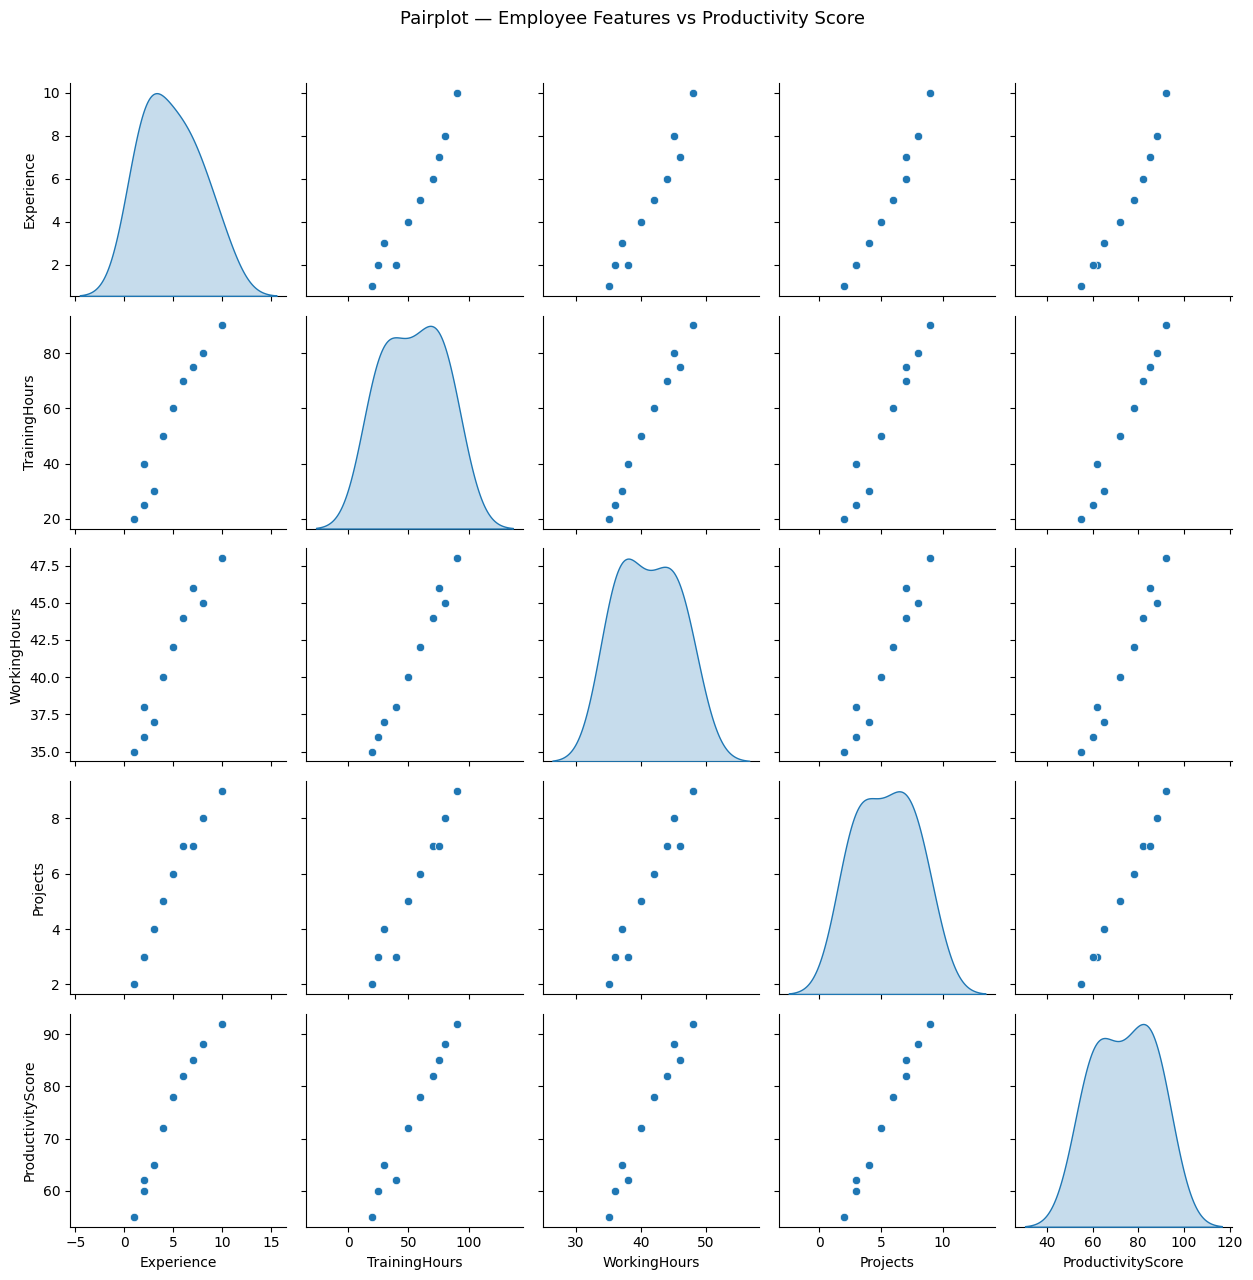

X_train_scaled [[-0.74136248 -0.23570226 -0.35575624 -0.76271277]
 [ 0.9884833   1.1785113   1.30443953  1.17873792]
 [-1.17382392 -1.1785113  -1.18585412 -1.24807544]
 [-0.74136248 -0.94280904 -0.90915483 -0.76271277]
 [ 0.12356041  0.23570226  0.19764235  0.20801257]
 [ 1.85340619  1.64991582  1.58113883  1.66410059]
 [-0.30890103 -0.70710678 -0.63245553 -0.2773501 ]]

Intercept: 69.1429

MSE : 13.6667
RMSE: 3.6968
R²  : 0.5816

Prediction Results:
 Actual  Predicted
     85       79.0
     78       77.0
     92       90.0


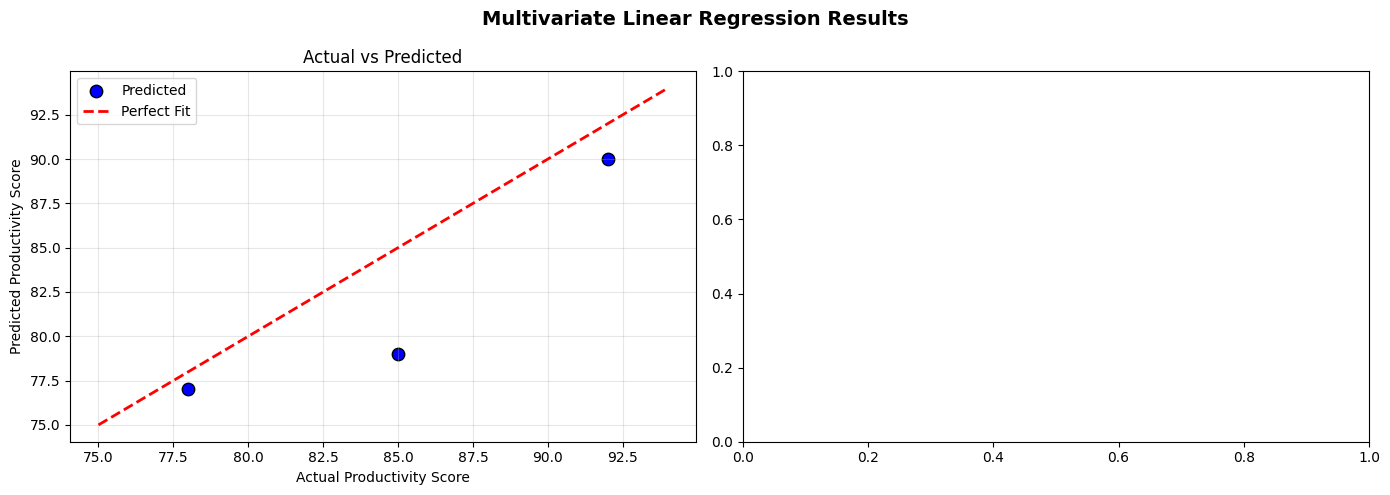

In [ ]:
data = {
    "Experience": [2, 5, 1, 8, 4, 10, 3, 6,7,2],
    "TrainingHours": [40, 60, 20, 80, 50, 90, 30, 70, 75,25],
    "WorkingHours": [38, 42, 35, 45, 40, 48, 37, 44, 46, 36],
    "Projects": [3, 6, 2, 8, 5, 9, 4, 7, 7,3],
    "ProductivityScore": [62, 78, 55, 88, 72, 92, 65, 82,85,60],
}

df = pd.DataFrame(data)

print(df.head())
print(f"\nShape: {df.shape}")
df.info()
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

sns.pairplot(df, diag_kind="kde")
plt.suptitle("Pairplot — Employee Features vs Productivity Score", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

X = df[["Experience", "TrainingHours", "WorkingHours", "Projects"]]
y = df["ProductivityScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled", X_train_scaled)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print(f"\nIntercept: {model.intercept_:.4f}")

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred, 2)
})
print("\nPrediction Results:")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Multivariate Linear Regression Results", fontsize=14, fontweight="bold")

# actual vs predicted
axes[0].scatter(y_test, y_pred, color="blue", edgecolors="black", s=80, label="Predicted")
min_val = min(y_test.min(), y_pred.min()) - 2
max_val = max(y_test.max(), y_pred.max()) + 2
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Fit")
axes[0].set_xlabel("Actual Productivity Score")
axes[0].set_ylabel("Predicted Productivity Score")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()